In [1]:
# Cell 1 — Imports + settings

import os                                              # file/folder utilities
import random                                          # Python random (for reproducible splits, etc.)
from pathlib import Path                               # safer path handling than raw strings
import json                                            # CHANGE: add JSON import so later cells can json.dump metrics/configs without NameError
import numpy as np                                     # arrays + math
import pandas as pd                                    # metadata tables (CSV)
import zarr                                            # load the saved Zarr dataset
import torch                                           # PyTorch core
import torch.nn as nn                                  # neural network layers
import torch.nn.functional as F                         # common functions (ReLU, etc.)
from torch.utils.data import Dataset, DataLoader        # dataset + minibatching
from sklearn.preprocessing import LabelEncoder          # convert hue strings -> class integers
from sklearn.model_selection import train_test_split    # stratified train/val/test splitting
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay            # evaluate predictions
from sklearn.metrics import classification_report       # precision/recall/F1 report
import matplotlib.pyplot as plt                         # plots (learning curves, confusion matrices)

# Reproducibility 

SEED = 0                                                # fixed seed 
SPLIT_SEED = SEED                                       # CHANGE: add dedicated dataset split seed (train/val/test indices) for clean split-control experiments
INIT_SEED_BASE = SEED                                   # CHANGE: add base seed used to derive per-trial model init seeds (multi-initial-weight runs)
SHUFFLE_SEED_BASE = SEED                                # CHANGE: add base seed used to derive per-trial DataLoader shuffle seeds (deterministic minibatch order when desired)

def set_all_seeds(seed: int, deterministic: bool = True) -> None:  # CHANGE: new helper to seed Python/NumPy/PyTorch consistently from one place
    seed = int(seed)                                    # CHANGE: coerce to int so all RNG APIs behave consistently

    os.environ.setdefault("PYTHONHASHSEED", str(seed))   # CHANGE: reduce hash nondeterminism (best set before Python starts; still helps in-notebook)

    if deterministic:                                   # CHANGE: gate deterministic-only environment flags
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # CHANGE: request deterministic CUDA matmul kernels (when using CUDA)

    random.seed(seed)                                   # CHANGE: seed Python RNG (affects any random.* usage)
    np.random.seed(seed)                                # CHANGE: seed NumPy RNG (affects any np.random usage)

    torch.manual_seed(seed)                             # CHANGE: seed PyTorch CPU RNG (affects weight init, shuffles, etc.)
    if torch.cuda.is_available():                       # CHANGE: only seed CUDA RNG if CUDA exists
        torch.cuda.manual_seed_all(seed)                # CHANGE: seed PyTorch CUDA RNG across all GPUs (if any)

    if deterministic:                                   # CHANGE: enforce deterministic backend behavior (at cost of speed)
        torch.backends.cudnn.deterministic = True       # CHANGE: force deterministic cuDNN algorithms when possible
        torch.backends.cudnn.benchmark = False          # CHANGE: disable cuDNN autotuner (prevents run-to-run variability)

        if hasattr(torch, "use_deterministic_algorithms"):  # CHANGE: enable deterministic algorithm enforcement if supported by this torch build
            try:                                        # CHANGE: prefer warn_only mode when available (avoids hard-crash on nondeterministic ops)
                torch.use_deterministic_algorithms(True, warn_only=True)  # CHANGE: enforce determinism but warn if an op lacks deterministic impl
            except TypeError:                           # CHANGE: older torch versions may not support warn_only
                torch.use_deterministic_algorithms(True)  # CHANGE: enforce determinism strictly (may raise if nondeterministic ops are used)

        if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):  # CHANGE: guard TF32 flags behind availability checks
            torch.backends.cuda.matmul.allow_tf32 = False  # CHANGE: disable TF32 (improves numerical reproducibility on Ampere+ GPUs)
        if hasattr(torch.backends, "cudnn"):             # CHANGE: guard TF32 flags behind cuDNN availability checks
            torch.backends.cudnn.allow_tf32 = False      # CHANGE: disable TF32 in cuDNN for tighter reproducibility
    else:                                               # CHANGE: non-deterministic mode (still keep benchmark off unless you explicitly want speed)
        torch.backends.cudnn.benchmark = False          # CHANGE: keep benchmark off by default to reduce variability even in non-deterministic mode

def get_torch_rng_state():                              # CHANGE: new helper to capture RNG state for save/restore around init-sensitive code
    state = {"cpu": torch.get_rng_state()}              # CHANGE: capture CPU RNG state exactly (not just a seed)
    if torch.cuda.is_available():                       # CHANGE: only capture CUDA states if CUDA exists
        state["cuda"] = torch.cuda.get_rng_state_all()  # CHANGE: capture RNG state for every CUDA device
    return state                                        # CHANGE: return combined CPU/CUDA RNG snapshot

def set_torch_rng_state(state) -> None:                 # CHANGE: new helper to restore RNG state captured by get_torch_rng_state
    torch.set_rng_state(state["cpu"])                   # CHANGE: restore CPU RNG state exactly
    if torch.cuda.is_available() and ("cuda" in state): # CHANGE: restore CUDA state only if available and present
        torch.cuda.set_rng_state_all(state["cuda"])     # CHANGE: restore RNG state for every CUDA device

def make_torch_generator(seed: int) -> torch.Generator: # CHANGE: new helper to create a dedicated Generator for deterministic DataLoader shuffles
    g = torch.Generator()                               # CHANGE: construct a standalone RNG generator (decouples shuffling from global RNG consumption)
    g.manual_seed(int(seed))                            # CHANGE: seed the generator deterministically
    return g                                            # CHANGE: return generator to pass into DataLoader(generator=g)

def seed_worker(worker_id: int) -> None:                # CHANGE: new helper for deterministic NumPy/Python RNG inside DataLoader workers
    worker_seed = torch.initial_seed() % (2**32)         # CHANGE: derive a per-worker seed from PyTorch's initial seed
    np.random.seed(worker_seed)                         # CHANGE: seed NumPy inside the worker (for any numpy ops in Dataset/transform)
    random.seed(worker_seed)                            # CHANGE: seed Python random inside the worker (for any random.* ops in Dataset/transform)

set_all_seeds(SEED)                                     # CHANGE: replace scattered seed lines with one centralized call (ensures consistent seeding)

# Device (CPU/GPU) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # pick GPU if available
print("Using device:", device)                            # confirmation in output

# Paths ---- EDIT THESE TWO PATHS ----
ZARR_PATH = Path("/Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/dataset.zarr")   
META_CSV  = Path("/Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/metadata.csv")   

# Path checks
assert ZARR_PATH.exists(), f"Zarr path not found: {ZARR_PATH}"          # fail if path is wrong
assert META_CSV.exists(),  f"Metadata CSV not found: {META_CSV}"        # fail if path is wrong
print("Found Zarr:", ZARR_PATH)                                         # confirm Zarr path
print("Found CSV :", META_CSV)                                          # confirm CSV path


Using device: cpu
Found Zarr: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/dataset.zarr
Found CSV : /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/metadata.csv


In [2]:
# Cell 2 — Load data from Zarr + metadata checks

# Load metadata table and open Zarr store and load arrays
meta = pd.read_csv(META_CSV)            # read the metadata.csv into a DataFrame
meta = meta.reset_index(drop=True)      # CHANGE: force a clean 0..N-1 row index so row i corresponds to stimulus i (critical for split + misclassification logging)
z = zarr.open(str(ZARR_PATH), mode="r") # open the Zarr folder in read-only mode
outs_fill = z["outs_fill"][:]           # load filled response maps into memory (N, C, H, W)
imgs = z["imgs"][:]                     # load RGB images (N, H, W, 3)
keys_order = [                          # CHANGE: normalize keys_order to list[str] (guards against bytes/np types causing key mismatches later)
    (k.decode() if isinstance(k, (bytes, bytearray)) else str(k))  # CHANGE: decode bytes keys (if any) and stringify everything for consistent downstream matching
    for k in z.attrs["keys_order"]      # CHANGE: iterate over stored keys_order attribute (same source, but normalized)
]

# Add stable stimulus indexing for reproducible logging across trials/splits
if "stimulus_index" not in meta.columns:                           # CHANGE: only add if it doesn't already exist (avoid overwriting user-provided columns)
    meta["stimulus_index"] = np.arange(len(meta), dtype=np.int64)  # CHANGE: explicit array-aligned stimulus index used to log misclassified RGB images and reproduce failures
else:                                                              # CHANGE: if user already has stimulus_index, validate it matches the row order used by outs_fill/imgs
    assert (meta["stimulus_index"].to_numpy() == np.arange(len(meta))).all(), (  # CHANGE: enforce that stimulus_index matches row order; otherwise logging would be wrong
        "meta['stimulus_index'] must match row order (0..N-1) so it aligns with outs_fill/imgs indices."
    )

# Data shape checks 
N = outs_fill.shape[0]                  # number of stimuli in outs_fill
N_meta = len(meta)                      # number of rows in metadata

assert N == N_meta, (f"Mismatch: outs_fill has N={N} but meta has N={N_meta}")
assert imgs.shape[0] == N, (f"Mismatch: imgs has N={imgs.shape[0]} but outs_fill has N={N}")
assert outs_fill.ndim == 4, (f"outs_fill should be 4D (N,C,H,W) but got shape {outs_fill.shape}")
assert imgs.ndim == 4 and imgs.shape[-1] == 3, (f"imgs should be 4D (N,H,W,3) but got shape {imgs.shape}")

# Check keys_order matches outs_fill channels
C = outs_fill.shape[1]                  # number of channels in outs_fill
assert len(keys_order) == C, (f"Mismatch: outs_fill has C={C} channels but keys_order has {len(keys_order)} keys")

# Checks on metadata 
assert "hue" in meta.columns, "metadata.csv must include a 'hue' column"  # required label column
expected_hues = {"red", "green", "blue", "yellow", "white"}               # allowed class names
assert meta["hue"].notna().all(), "Found NaNs in meta['hue']"             # no missing labels
hues_found = set(meta["hue"].astype(str).unique())                         # unique labels present
unknown = sorted(hues_found - expected_hues)                                # labels other than expected
missing = sorted(expected_hues - hues_found)                                # expected labels not present
assert len(unknown) == 0, f"Found unexpected hue labels: {unknown}"         # fail if any unknown labels

# Print data summary
print("Loaded outs_fill:", outs_fill.shape, outs_fill.dtype)               # confirm shape + dtype
print("Loaded imgs    :", imgs.shape, imgs.dtype)                           # confirm shape + dtype
print("Loaded meta    :", meta.shape)                                       # confirm metadata size
print("Channels (C):", C)                                                   # print channel count
print("keys_order:", keys_order)                                            # print channel names
print("Hue counts:\n", meta["hue"].value_counts())                          # show class balance
if missing:                                                                 # not an error, but useful info
    print("Note: missing expected hues in this dataset:", missing)          


Loaded outs_fill: (250, 8, 1000, 1000) float32
Loaded imgs    : (250, 1000, 1000, 3) float32
Loaded meta    : (250, 11)
Channels (C): 8
keys_order: ['l_on', 'l_off', 'm_on', 'm_off', 'l_h2_on', 'm_h2_on', 'l_h2_off', 'm_h2_off']
Hue counts:
 hue
red       50
green     50
blue      50
yellow    50
white     50
Name: count, dtype: int64


In [3]:
# Cell 3 — Encode labels + make stratified splits (train/val/test)

try:                                                            # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining SPLIT_SEED)
    SPLIT_SEED                                                   # CHANGE: reference check — if SPLIT_SEED exists, do nothing
except NameError:                                                # CHANGE: if SPLIT_SEED is missing, define a safe default
    SPLIT_SEED = 0                                               # CHANGE: fallback split seed (keeps behavior equivalent to the old SEED=0 default)

TEST_FRAC = 0.15                                                # fraction of data reserved for final test set
VAL_FRAC  = 0.15                                                # fraction of total data reserved for validation set
le = LabelEncoder()                                             # create the label encoder object
y_str = meta["hue"].astype(str).values                          # hue labels as clean strings (length N)
y = le.fit_transform(y_str)                                     # encode hues -> ints (0..C-1), length N
class_names = list(le.classes_)                                 # list of class names in encoder order
n_classes = len(class_names)                                    # number of classes (expect 5 hues)
all_idx = meta["stimulus_index"].to_numpy(dtype=int)            # CHANGE: use explicit stimulus_index for indices (guarantees alignment to outs_fill/imgs and supports misclassification logging)

def make_stratified_splits(all_idx, y, split_seed, test_frac, val_frac):  # CHANGE: new helper so we can generate many dataset splits by varying split_seed
    """Return (train_idx, val_idx, test_idx) with stratification and reproducible randomness."""  # CHANGE: document purpose (multi-split experiments)

    trainval_idx, test_idx = train_test_split(                  # CHANGE: Split 1 wrapped in helper so we can rerun with different split_seed values
        all_idx,                                                # CHANGE: use provided indices (must match arrays in outs_fill/imgs)
        test_size=test_frac,                                    # CHANGE: use provided test_frac (instead of fixed TEST_FRAC inside helper)
        stratify=y,                                             # CHANGE: preserve hue proportions
        random_state=int(split_seed)                            # CHANGE: use split_seed (controls dataset split reproducibly)
    )

    val_frac_within_trainval = val_frac / (1.0 - test_frac)     # CHANGE: compute within-trainval validation fraction based on provided fracs
    y_trainval = y[trainval_idx]                                # CHANGE: labels for trainval subset (for stratify)

    train_idx, val_idx = train_test_split(                      # CHANGE: Split 2 wrapped in helper so we can rerun with different split_seed values
        trainval_idx,                                           # CHANGE: indices in the trainval subset
        test_size=val_frac_within_trainval,                     # CHANGE: size of val split (relative to trainval)
        stratify=y_trainval,                                    # CHANGE: preserve hue proportions in val
        random_state=int(split_seed)                            # CHANGE: use the same split_seed for deterministic train/val split within this dataset split
    )

    train_idx = np.sort(train_idx)                              # CHANGE: ensure deterministic ordering of returned indices (helps reproducible logging/printing)
    val_idx   = np.sort(val_idx)                                # CHANGE: ensure deterministic ordering of returned indices (helps reproducible logging/printing)
    test_idx  = np.sort(test_idx)                               # CHANGE: ensure deterministic ordering of returned indices (helps reproducible logging/printing)
    return train_idx, val_idx, test_idx                          # CHANGE: return the three splits for reuse elsewhere (multi-split loops)

train_idx, val_idx, test_idx = make_stratified_splits(          # CHANGE: generate the default split via helper (enables multi-split experiments by varying SPLIT_SEED)
    all_idx=all_idx,                                            # CHANGE: pass in stimulus-aligned indices
    y=y,                                                        # CHANGE: pass encoded labels for stratification
    split_seed=SPLIT_SEED,                                      # CHANGE: use the dedicated split seed (controls dataset split reproducibly)
    test_frac=TEST_FRAC,                                        # CHANGE: pass configured test fraction
    val_frac=VAL_FRAC                                           # CHANGE: pass configured val fraction
)

SPLIT_RECORD = {                                                # CHANGE: keep a structured record of the split config + indices for later logging/plotting across trials/splits
    "split_seed": int(SPLIT_SEED),                               # CHANGE: record which split seed produced this split
    "test_frac": float(TEST_FRAC),                               # CHANGE: record fractions used (useful when comparing experiments)
    "val_frac": float(VAL_FRAC),                                 # CHANGE: record fractions used (useful when comparing experiments)
    "train_idx": train_idx,                                      # CHANGE: store indices for downstream reuse (e.g., reruns with different init seeds)
    "val_idx": val_idx,                                          # CHANGE: store indices for downstream reuse
    "test_idx": test_idx                                         # CHANGE: store indices for downstream reuse
}

# Print label mapping
print("LabelEncoder classes (int -> hue):")                      # header line
for i, name in enumerate(class_names):                           # loop through class list
    print(f"  {i} -> {name}")                                    # show mapping

# Print split sizes
print("\nSplit sizes:")                                          # header line
print("  Train:", len(train_idx))                                # number of training examples
print("  Val  :", len(val_idx))                                  # number of validation examples
print("  Test :", len(test_idx))                                 # number of test examples

# Print class counts per split 
print("\nClass counts per split:")                               # header line
print("  Train:\n", pd.Series(le.inverse_transform(y[train_idx])).value_counts())  # hue counts in train
print("  Val:\n",   pd.Series(le.inverse_transform(y[val_idx])).value_counts())    # hue counts in val
print("  Test:\n",  pd.Series(le.inverse_transform(y[test_idx])).value_counts())   # hue counts in test


LabelEncoder classes (int -> hue):
  0 -> blue
  1 -> green
  2 -> red
  3 -> white
  4 -> yellow

Split sizes:
  Train: 174
  Val  : 38
  Test : 38

Class counts per split:
  Train:
 red       35
blue      35
yellow    35
white     35
green     34
Name: count, dtype: int64
  Val:
 red       8
green     8
blue      8
yellow    7
white     7
Name: count, dtype: int64
  Test:
 green     8
yellow    8
white     8
red       7
blue      7
Name: count, dtype: int64


In [4]:
# Cell 4 — Define Dataset + DataLoaders

# Choose which channel-set to use for this run
CHANNEL_SET = "all8"                                              # options: "all8", "classic4", "h2_4"

# Define the 3 channel-sets 
keys_all8 = ["l_on","l_off","m_on","m_off","l_h2_on","m_h2_on","l_h2_off","m_h2_off"]     # 8 channels
keys_classic4 = ["l_on","l_off","m_on","m_off"]                                           # 4 classical
keys_h2_4 = ["l_h2_on","m_h2_on","l_h2_off","m_h2_off"]                                   # 4 H2+

# Pick the key list based for the channel-set
if CHANNEL_SET == "all8":                                          # if using all 8 channels
    keys_subset = keys_all8                                        # choose all 8
elif CHANNEL_SET == "classic4":                                    # if using classic 4
    keys_subset = keys_classic4                                    # choose classic 4
elif CHANNEL_SET == "h2_4":                                        # if using H2 4
    keys_subset = keys_h2_4                                        # choose H2 4
else:                                                              # if typed something else
    raise ValueError("CHANNEL_SET must be 'all8', 'classic4', or 'h2_4'")  # stop with clear error

# Map key name to channel index in outs_fill
key_to_idx = {k: i for i, k in enumerate(keys_order)}              # dictionary: key string to channel integer
channel_idxs = [key_to_idx[k] for k in keys_subset]                # list of channel indices in correct order
C = len(channel_idxs)                                              # number of channels for this run

print("Using CHANNEL_SET:", CHANNEL_SET)                            # print which set you selected
print("Channels (keys):", keys_subset)                              # print key names
print("Channels (idxs):", channel_idxs)                             # print numeric indices
print("C =", C)                                                     # print channel count

# Define the dataset
class RetinaHueDataset(Dataset):                                    # dataset class
    def __init__(self, outs_fill, y, indices, channel_idxs):        # constructor
        self.outs_fill = outs_fill                                  # numpy array (N, C_all, H, W)
        self.y = y                                                  # numpy array (N,)
        self.indices = np.asarray(indices, dtype=int)               # indices for this split (train/val/test)
        self.channel_idxs = np.asarray(channel_idxs, dtype=int)     # which channels to use (subset)

    def __len__(self):                                              # length required by PyTorch
        return len(self.indices)                                    # number of items in this split

    def __getitem__(self, i):                                       # get one item by local index
        sid = int(self.indices[i])                                  # global stimulus id (0..N-1)
        x_np = self.outs_fill[sid, self.channel_idxs, :, :]         # select channels into shape (C, H, W)
        x = torch.from_numpy(np.asarray(x_np, dtype=np.float32))    # convert to torch float32 tensor
        y_int = int(self.y[sid])                                    # label integer for this stimulus
        y_t = torch.tensor(y_int, dtype=torch.long)                 # convert to torch int64 (class label)
        return x, y_t                                               # return (input, label)

# Create Dataset objects for each split
ds_train = RetinaHueDataset(outs_fill, y, train_idx, channel_idxs)  # training dataset
ds_val   = RetinaHueDataset(outs_fill, y, val_idx,   channel_idxs)  # validation dataset
ds_test  = RetinaHueDataset(outs_fill, y, test_idx,  channel_idxs)  # test dataset

# Create DataLoaders, shuffle only for training
BATCH_SIZE = 5                                                      # small batch (1000x1000 maps are big)
NUM_WORKERS = 0                                                     # safe default for Jupyter/macOS

try:                                                               # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining SHUFFLE_SEED_BASE)
    SHUFFLE_SEED_BASE                                               # CHANGE: reference check — if SHUFFLE_SEED_BASE exists, do nothing
except NameError:                                                   # CHANGE: if SHUFFLE_SEED_BASE is missing, define a safe default
    SHUFFLE_SEED_BASE = 0                                           # CHANGE: fallback shuffle base seed (keeps behavior equivalent to prior default randomness control)

RUN_SHUFFLE_SEED = int(SHUFFLE_SEED_BASE)                           # CHANGE: per-run shuffle seed (later, multi-trial code will set RUN_SHUFFLE_SEED = SHUFFLE_SEED_BASE + trial_id)
dl_train_generator = make_torch_generator(RUN_SHUFFLE_SEED)         # CHANGE: dedicated Generator so training shuffle is deterministic and decoupled from global torch RNG consumption

dl_train = DataLoader(                                               # train loader
    ds_train,                                                        # training dataset
    batch_size=BATCH_SIZE,                                           # how many per minibatch
    shuffle=True,                                                    # shuffle ONLY for training
    num_workers=NUM_WORKERS,                                         # workers (0 = simplest)
    pin_memory=False,                                                # keep False since we are on CPU
    generator=dl_train_generator,                                    # CHANGE: make training shuffle order reproducible for a given RUN_SHUFFLE_SEED (important for multi-trial comparisons)
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None          # CHANGE: seed NumPy/Python inside workers if you later set NUM_WORKERS>0 (no-op for 0)
)

dl_val = DataLoader(                                                 # val loader
    ds_val,                                                          # validation dataset
    batch_size=BATCH_SIZE,                                           # same batch size
    shuffle=False,                                                   # do NOT shuffle val
    num_workers=NUM_WORKERS,                                         # workers
    pin_memory=False,                                                # CPU
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None          # CHANGE: seed NumPy/Python inside workers if you later set NUM_WORKERS>0 (keeps val deterministic too)
)

dl_test = DataLoader(                                                # test loader
    ds_test,                                                         # test dataset
    batch_size=BATCH_SIZE,                                           # same batch size
    shuffle=False,                                                   # do NOT shuffle test
    num_workers=NUM_WORKERS,                                         # workers
    pin_memory=False,                                                # CPU
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None          # CHANGE: seed NumPy/Python inside workers if you later set NUM_WORKERS>0 (keeps test deterministic too)
)

# Quick sanity check: print shapes
xb, yb = next(iter(dl_train))                                        # get one batch from train loader
print("Batch x shape:", tuple(xb.shape))                             # expect (B, C, H, W)
print("Batch y shape:", tuple(yb.shape))                             # expect (B,)
print("x dtype:", xb.dtype, " y dtype:", yb.dtype)                   # expect float32 and int64


Using CHANNEL_SET: all8
Channels (keys): ['l_on', 'l_off', 'm_on', 'm_off', 'l_h2_on', 'm_h2_on', 'l_h2_off', 'm_h2_off']
Channels (idxs): [0, 1, 2, 3, 4, 5, 6, 7]
C = 8
Batch x shape: (5, 8, 1000, 1000)
Batch y shape: (5,)
x dtype: torch.float32  y dtype: torch.int64


In [5]:
# Cell 5 — Define the CNN model (logits + CrossEntropyLoss)

try:                                                            # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining INIT_SEED_BASE)
    INIT_SEED_BASE                                               # CHANGE: reference check — if INIT_SEED_BASE exists, do nothing
except NameError:                                                # CHANGE: if INIT_SEED_BASE is missing, define a safe default
    INIT_SEED_BASE = 0                                           # CHANGE: fallback init base seed (keeps behavior equivalent to prior default randomness control)

RUN_INIT_SEED = int(INIT_SEED_BASE)                              # CHANGE: per-run init seed (later, multi-trial code will set RUN_INIT_SEED = INIT_SEED_BASE + trial_id)

try:                                                            # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining RNG state helpers)
    get_torch_rng_state                                          # CHANGE: reference check — if get_torch_rng_state exists, do nothing
    set_torch_rng_state                                          # CHANGE: reference check — if set_torch_rng_state exists, do nothing
except NameError:                                                # CHANGE: if RNG state helpers are missing, define minimal fallbacks (CPU-only)
    def get_torch_rng_state():                                   # CHANGE: fallback RNG snapshot helper (CPU-only) to avoid NameError if Cell 1 wasn't run
        return {"cpu": torch.get_rng_state()}                    # CHANGE: capture CPU RNG state exactly (not just a seed)
    def set_torch_rng_state(state) -> None:                      # CHANGE: fallback RNG restore helper (CPU-only) to avoid NameError if Cell 1 wasn't run
        torch.set_rng_state(state["cpu"])                        # CHANGE: restore CPU RNG state exactly

def build_seeded_model(in_channels, n_classes, init_seed, device, example_batch=None):  # CHANGE: new helper to build a model with controlled init_seed (supports multi-init trials cleanly)
    rng_state = get_torch_rng_state()                            # CHANGE: save current RNG state so model construction/init does not contaminate later randomness
    torch.manual_seed(int(init_seed))                            # CHANGE: set torch CPU seed so weight initialization is controlled by init_seed
    if torch.cuda.is_available():                                # CHANGE: if CUDA exists, also seed CUDA RNG (future-proof if you later construct/move on GPU)
        torch.cuda.manual_seed_all(int(init_seed))               # CHANGE: set torch CUDA seed so any CUDA-side randomness is controlled by init_seed

    model = RetinaCNN(in_channels=in_channels, n_classes=n_classes, first_kernel=3, first_stride=2, first_padding=1)  # CHANGE: construct model *after* seeding so init weights are reproducible
    model = model.to(device)                                     # CHANGE: move model to the active device immediately (prevents accidental CPU/GPU mismatches)

    if example_batch is not None:                                # CHANGE: initialize LazyLinear weights deterministically on a controlled first forward pass
        was_training = model.training                            # CHANGE: remember current train/eval mode so we can restore it after initialization
        model.eval()                                             # CHANGE: set eval mode for initialization pass (no training-only behavior like dropout; not used here but safe)
        with torch.no_grad():                                    # CHANGE: avoid tracking gradients during the initialization forward
            _ = model(example_batch.to(device))                  # CHANGE: run one forward to trigger LazyLinear parameter init under init_seed control
        model.train(was_training)                                # CHANGE: restore original train/eval mode

    set_torch_rng_state(rng_state)                               # CHANGE: restore RNG state so downstream randomness is unaffected by model init work
    return model                                                 # CHANGE: return the seeded-and-initialized model

# Define the CNN as a PyTorch Module
class RetinaCNN(nn.Module):  # model class
    def __init__(self, in_channels, n_classes=5, first_kernel=3, first_stride=2, first_padding=1):  # constructor
        super().__init__()  # initialize nn.Module base class
        self.conv1 = nn.Conv2d(  # first convolution layer
            in_channels=in_channels,  # input channels (C = 8 or 4)
            out_channels=16,          # number of filters
            kernel_size=first_kernel, # k (e.g., 3)
            stride=first_stride,      # s (e.g., 2)
            padding=first_padding     # p (e.g., 1)
        )
        self.relu = nn.ReLU(inplace=True)  # ReLU nonlinearity
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 2x2 max pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)   # 3x3 conv
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)   # 3x3 conv
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # 3x3 conv

        # Classifier head 
        self.fc1 = nn.LazyLinear(256)  # first dense layer: (128*H'*W'); 256 (Lazy infers input dim)
        self.fc2 = nn.Linear(256, 128) # second dense layer: 256 to 128 (latent)
        self.fc3 = nn.Linear(128, n_classes)  # final dense: 128 to 5 logits (one per hue)

    def forward(self, x):  # forward pass (x shape: (B, C, H, W))
        x = self.conv1(x)  # (B, 16, ..., ...)
        x = self.relu(x)   # apply ReLU
        x = self.pool(x)   # max pool

        x = self.conv2(x)  # (B, 32, ..., ...)
        x = self.relu(x)   # ReLU
        x = self.pool(x)   # max pool

        x = self.conv3(x)  # (B, 64, ..., ...)
        x = self.relu(x)   # ReLU
        x = self.pool(x)   # max pool

        x = self.conv4(x)  # (B, 128, ..., ...)
        x = self.relu(x)   # ReLU
        x = self.pool(x)   # max pool

        x = torch.flatten(x, start_dim=1)  # flatten: (B, 128, H', W') to (B, 128*H'*W')

        x = self.fc1(x)    # (B, 256)
        x = self.relu(x)   # ReLU

        latent = self.fc2(x)  # (B, 128) latent embedding
        latent = self.relu(latent)  # ReLU

        logits = self.fc3(latent)  # (B, 5) raw scores, logits
        return logits, latent      # return both for classification + training analysis


# Create one model for the channel-set pickedin Cell 4 
x0, y0 = ds_train[0]                                         # CHANGE: grab one sample from ds_train without consuming dl_train shuffling state (keeps training shuffle reproducible)
xb = x0.unsqueeze(0)                                         # CHANGE: add batch dimension so xb matches expected model input shape (B, C, H, W)
model = build_seeded_model(in_channels=C, n_classes=n_classes, init_seed=RUN_INIT_SEED, device=device, example_batch=xb)  # CHANGE: build a deterministically-initialized model (incl. LazyLinear init)

# Sanity check: run one batch through the model 
with torch.no_grad():                                        # CHANGE: avoid tracking gradients during the sanity forward pass
    logits, latent = model(xb.to(device))                     # CHANGE: forward pass on the correct device using the same xb used for LazyLinear init
print("logits shape:", tuple(logits.shape))                   # expect (B, 5)
print("latent shape:", tuple(latent.shape))                   # expect (B, 128)


logits shape: (1, 5)
latent shape: (1, 128)


In [6]:
# Cell 6 — Training utilities (train/eval loops + history)

# Loss function: CrossEntropyLoss expects logits (no softmax) and class indices (0..n_classes-1)
criterion = nn.CrossEntropyLoss()                               # computes softmax + NLL internally

# Optimizer: Adam 
LR = 1e-4                                                       # learning rate 

try:                                                            # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining device)
    device                                                      # CHANGE: reference check — if device exists, do nothing
except NameError:                                                # CHANGE: if device is missing, define a safe default
    device = torch.device("cpu")                                 # CHANGE: fallback device (keeps training functional if Cell 1 wasn’t run)

def make_optimizer(model, lr=LR):                                # CHANGE: helper to create a fresh optimizer per model (needed for multi-trial/multi-split runs)
    return torch.optim.Adam(model.parameters(), lr=lr)            # CHANGE: return a new Adam optimizer bound to this model’s parameters

optimizer = make_optimizer(model, lr=LR)                          # CHANGE: create optimizer via helper (still provides `optimizer` for the current model, but makes multi-run usage explicit)

def _accuracy_from_logits(logits, y_true):
    preds = torch.argmax(logits, dim=1)                          # predicted class index per sample
    correct = (preds == y_true).sum().item()                     # number correct in this batch
    total = int(y_true.numel())                                  # number of labels in this batch
    return correct, total                                        # return counts for accumulation

def train_one_epoch(model, dataloader, optimizer, criterion, device=device):  # CHANGE: add device parameter (defaults to global `device`) for GPU support + reproducible multi-run calls
    model.train()                                                # set model to training mode 
    running_loss = 0.0                                           # sum of losses across batches weighted by batch size
    running_correct = 0                                          # sum of correct predictions across batches
    running_total = 0                                            # sum of total samples across batches
    for xb, yb in dataloader:                                    # loop over minibatches
        xb = xb.to(device=device, dtype=torch.float32)           # CHANGE: move inputs to device and enforce float32 (supports CPU/GPU consistently)
        yb = yb.to(device=device, dtype=torch.long)              # CHANGE: move labels to device and enforce int64 (required by CrossEntropyLoss)
        optimizer.zero_grad()                                    # clear old gradients 
        logits, latent = model(xb)                               # forward pass
        loss = criterion(logits, yb)                             # compute classification loss
        loss.backward()                                          # backprop: compute gradients
        optimizer.step()                                         # update model weights
        bs = int(yb.size(0))                                     # batch size 
        running_loss += loss.item() * bs                         # accumulate total loss, sum over samples
        correct, total = _accuracy_from_logits(logits, yb)       # batch correct/total
        running_correct += correct                               # accumulate correct predictions
        running_total += total                                   # accumulate sample count
    avg_loss = running_loss / max(1, running_total)              # average loss per sample
    avg_acc = running_correct / max(1, running_total)            # accuracy over the whole epoch
    return avg_loss, avg_acc                                     # return epoch metrics

@torch.no_grad()                                                 # no gradients for evaluation
def eval_one_epoch(model, dataloader, criterion, device=device):  # CHANGE: add device parameter (defaults to global `device`) for GPU support + reproducible multi-run calls
    model.eval()                                                 # set model to eval mode
    running_loss = 0.0                                           # sum of losses across batches weighted by batch size
    running_correct = 0                                          # sum of correct predictions across batches
    running_total = 0                                            # sum of total samples across batches
    for xb, yb in dataloader:                                    # loop over minibatches
        xb = xb.to(device=device, dtype=torch.float32)           # CHANGE: move inputs to device and enforce float32 (supports CPU/GPU consistently)
        yb = yb.to(device=device, dtype=torch.long)              # CHANGE: move labels to device and enforce int64 (required by CrossEntropyLoss)
        logits, latent = model(xb)                               # forward pass
        loss = criterion(logits, yb)                             # compute loss
        bs = int(yb.size(0))                                     # batch size
        running_loss += loss.item() * bs                         # accumulate total loss
        correct, total = _accuracy_from_logits(logits, yb)       # batch correct/total
        running_correct += correct                               # accumulate correct predictions
        running_total += total                                   # accumulate sample count
    avg_loss = running_loss / max(1, running_total)              # average loss per sample
    avg_acc = running_correct / max(1, running_total)            # accuracy over the full eval set
    return avg_loss, avg_acc                                     # return epoch metrics

def train_model(model, dl_train, dl_val, optimizer, criterion, epochs=10,  # (signature line unchanged except where noted below)
                save_best=False, ckpt_path="best_model.pt", device=device):  # CHANGE: add device parameter so training/validation are correct on CPU/GPU in multi-run loops
    """
    Train for multiple epochs and return a history dict.
    If save_best=True, saves the model state_dict with best val accuracy.
    """
    history = {                                                  # store curves for plotting later
        "train_loss": [], "train_acc": [],                       # training metrics per epoch
        "val_loss": [], "val_acc": []                            # validation metrics per epoch
    }

    best_val_acc = -1.0                                          # track best validation accuracy so far
    best_epoch = -1                                              # CHANGE: track which epoch achieved best validation accuracy (useful for multi-trial comparisons)

    for epoch in range(1, epochs + 1):                           # epoch loop
        train_loss, train_acc = train_one_epoch(                 # run one training epoch
            model, dl_train, optimizer, criterion, device=device  # CHANGE: pass device through so data/model are on same device reliably
        )
        val_loss, val_acc = eval_one_epoch(                      # run one validation epoch
            model, dl_val, criterion, device=device              # CHANGE: pass device through so eval uses correct device reliably
        )

        history["train_loss"].append(train_loss)                 # record train loss
        history["train_acc"].append(train_acc)                   # record train accuracy
        history["val_loss"].append(val_loss)                     # record val loss
        history["val_acc"].append(val_acc)                       # record val accuracy

        print(                                                   # epoch printout
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}"
        )

        if save_best and (val_acc > best_val_acc):               # check if this is a new best model
            best_val_acc = val_acc                               # update best val acc
            best_epoch = epoch                                   # CHANGE: record the epoch index of the best checkpoint (supports later aggregation/plotting)
            torch.save(model.state_dict(), ckpt_path)            # save weights only
            print(f"  saved best checkpoint -> {ckpt_path} (val acc {best_val_acc:.4f})")  # confirm save

    history["best_val_acc"] = float(best_val_acc)                # CHANGE: store best validation accuracy in history (useful for summarizing many trials/splits)
    history["best_epoch"] = int(best_epoch)                      # CHANGE: store which epoch was best (useful when comparing convergence across trials)
    history["ckpt_path"] = ckpt_path if save_best else None       # CHANGE: store checkpoint path (or None) so downstream code knows where the best weights were saved

    return history                                               # return learning curves


In [7]:
# Cell 7 — Run 3 CNN experiments (all8 vs classic4 vs h2_4) + final test eval

# 1) Settings for all runs
SEED = 0                                                     # fixed seed for reproducibility
EPOCHS = 10                                                  # fixed number of epochs per run
BATCH_SIZE = 5                                               # keep small (1000x1000 maps are big)
LR = 1e-4                                                    # learning rate for Adam
NUM_WORKERS = 0                                              # safest default for Jupyter/macOS

try:                                                        # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining device)
    device                                                  # CHANGE: reference check — if device exists, do nothing
except NameError:                                            # CHANGE: if device is missing, define a safe default
    device = torch.device("cpu")                             # CHANGE: fallback device so code runs even if Cell 1 wasn't executed

try:                                                        # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining seed bases)
    SPLIT_SEED                                               # CHANGE: reference check — if SPLIT_SEED exists, do nothing
    INIT_SEED_BASE                                           # CHANGE: reference check — if INIT_SEED_BASE exists, do nothing
    SHUFFLE_SEED_BASE                                        # CHANGE: reference check — if SHUFFLE_SEED_BASE exists, do nothing
except NameError:                                            # CHANGE: if seed base variables are missing, define safe defaults
    SPLIT_SEED = SEED                                        # CHANGE: fallback split seed base (keeps prior behavior when SEED=0)
    INIT_SEED_BASE = SEED                                    # CHANGE: fallback init seed base (keeps prior behavior when SEED=0)
    SHUFFLE_SEED_BASE = SEED                                 # CHANGE: fallback shuffle seed base (keeps prior behavior when SEED=0)

try:                                                        # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining helpers)
    make_torch_generator                                     # CHANGE: reference check — if make_torch_generator exists, do nothing
    seed_worker                                              # CHANGE: reference check — if seed_worker exists, do nothing
except NameError:                                            # CHANGE: if helpers are missing, define minimal fallbacks
    def make_torch_generator(seed: int) -> torch.Generator:   # CHANGE: fallback generator helper (keeps deterministic shuffle support)
        g = torch.Generator()                                # CHANGE: create a standalone generator
        g.manual_seed(int(seed))                             # CHANGE: seed generator deterministically
        return g                                             # CHANGE: return generator for DataLoader(generator=...)
    def seed_worker(worker_id: int) -> None:                 # CHANGE: fallback worker seeding helper (keeps determinism if NUM_WORKERS>0)
        worker_seed = torch.initial_seed() % (2**32)          # CHANGE: derive per-worker seed from torch
        np.random.seed(worker_seed)                          # CHANGE: seed NumPy within worker
        random.seed(worker_seed)                             # CHANGE: seed Python random within worker

try:                                                        # CHANGE: allow this cell to run even if executed standalone (without Cell 5/6 helpers)
    build_seeded_model                                       # CHANGE: reference check — if build_seeded_model exists, do nothing
    make_optimizer                                           # CHANGE: reference check — if make_optimizer exists, do nothing
except NameError:                                            # CHANGE: if helpers are missing, define minimal fallbacks
    def build_seeded_model(in_channels, n_classes, init_seed, device, example_batch=None):  # CHANGE: fallback seeded model builder (CPU-safe)
        torch.manual_seed(int(init_seed))                    # CHANGE: seed torch so init is controlled
        model = RetinaCNN(in_channels=in_channels, n_classes=n_classes, first_kernel=3, first_stride=2, first_padding=1)  # CHANGE: construct model after seeding
        model = model.to(device)                             # CHANGE: move model to device
        if example_batch is not None:                        # CHANGE: trigger LazyLinear init under controlled seed
            model.eval()                                     # CHANGE: eval mode for init pass
            with torch.no_grad():                            # CHANGE: no grads for init pass
                _ = model(example_batch.to(device))          # CHANGE: forward to initialize LazyLinear weights
            model.train()                                    # CHANGE: restore train mode (default)
        return model                                         # CHANGE: return model
    def make_optimizer(model, lr=LR):                        # CHANGE: fallback optimizer factory
        return torch.optim.Adam(model.parameters(), lr=lr)   # CHANGE: create optimizer bound to this model

try:                                                        # CHANGE: allow this cell to run even if executed standalone (without Cell 3 helper)
    make_stratified_splits                                   # CHANGE: reference check — if make_stratified_splits exists, do nothing
except NameError:                                            # CHANGE: if split helper is missing, define a minimal version here
    def make_stratified_splits(all_idx, y, split_seed, test_frac, val_frac):  # CHANGE: fallback split helper for multi-split experiments
        trainval_idx, test_idx = train_test_split(           # CHANGE: Split 1 (train+val vs test)
            all_idx, test_size=test_frac, stratify=y, random_state=int(split_seed)  # CHANGE: stratified, seeded split
        )
        val_frac_within_trainval = val_frac / (1.0 - test_frac)  # CHANGE: compute within-trainval val fraction
        y_trainval = y[trainval_idx]                         # CHANGE: labels for stratify in split 2
        train_idx, val_idx = train_test_split(               # CHANGE: Split 2 (train vs val within trainval)
            trainval_idx, test_size=val_frac_within_trainval, stratify=y_trainval, random_state=int(split_seed)  # CHANGE: stratified, seeded split
        )
        return np.sort(train_idx), np.sort(val_idx), np.sort(test_idx)  # CHANGE: return sorted indices for deterministic order

try:                                                        # CHANGE: allow this cell to run even if executed standalone (without Cell 3 vars)
    TEST_FRAC                                                # CHANGE: reference check — if TEST_FRAC exists, do nothing
    VAL_FRAC                                                 # CHANGE: reference check — if VAL_FRAC exists, do nothing
except NameError:                                            # CHANGE: if fractions are missing, define defaults matching earlier cells
    TEST_FRAC = 0.15                                         # CHANGE: fallback test fraction
    VAL_FRAC = 0.15                                          # CHANGE: fallback val fraction

# Multi-run controls (new ideas)
RUN_MULTI_INIT = True                                        # CHANGE: toggle idea (1): run multiple trials with different randomized initial weights per channel-set
N_INIT_TRIALS = 5                                            # CHANGE: number of distinct init-weight trials per channel-set (edit as desired)
RUN_MULTI_SPLIT = True                                       # CHANGE: toggle idea (2): run multiple dataset splits (train/val/test) with different split seeds
N_SPLITS = 3                                                 # CHANGE: number of dataset splits to evaluate (edit as desired)

# 2) Define the 3 channel-sets 
channel_sets = {                                             # mapping name to list of channel keys
    "all8":      ["l_on","l_off","m_on","m_off","l_h2_on","m_h2_on","l_h2_off","m_h2_off"],
    "classic4":  ["l_on","l_off","m_on","m_off"],
    "h2_4":      ["l_h2_on","m_h2_on","l_h2_off","m_h2_off"],
}

# 3) Map key name to channel index in outs_fill 
key_to_idx = {k: i for i, k in enumerate(keys_order)}        # dict: channel name to integer index

# 4) Build datasets + dataloaders for a chosen channel subset
def make_loaders_for_keys(keys_subset, train_idx, val_idx, test_idx, shuffle_seed):  # CHANGE: add split indices + shuffle_seed so loaders are reproducible per split/trial
    channel_idxs = [key_to_idx[k] for k in keys_subset]      # convert key strings to numeric indices
    ds_train = RetinaHueDataset(outs_fill, y, train_idx, channel_idxs)  # CHANGE: build train dataset using the provided train_idx (supports multi-split runs)
    ds_val   = RetinaHueDataset(outs_fill, y, val_idx,   channel_idxs)  # CHANGE: build val dataset using the provided val_idx (supports multi-split runs)
    ds_test  = RetinaHueDataset(outs_fill, y, test_idx,  channel_idxs)  # CHANGE: build test dataset using the provided test_idx (supports multi-split runs)

    dl_train_generator = make_torch_generator(int(shuffle_seed))        # CHANGE: dedicated generator makes training shuffle deterministic and decoupled from global RNG

    dl_train = DataLoader(                                   # training loader
        ds_train,                                            # training dataset
        batch_size=BATCH_SIZE,                               # minibatch size
        shuffle=True,                                        # shuffle only for training
        num_workers=NUM_WORKERS,                             # workers
        pin_memory=False,                                    # CPU-safe
        generator=dl_train_generator,                        # CHANGE: seeded shuffle order (important for clean multi-trial comparisons)
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None  # CHANGE: deterministic NumPy/Python RNG in workers if NUM_WORKERS>0
    )
    dl_val = DataLoader(                                     # validation loader
        ds_val,                                              # validation dataset
        batch_size=BATCH_SIZE,                               # minibatch size
        shuffle=False,                                       # No shuffle for validation
        num_workers=NUM_WORKERS,                             # workers
        pin_memory=False,                                    # CPU-safe
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None  # CHANGE: deterministic worker seeding if NUM_WORKERS>0
    )
    dl_test = DataLoader(                                    # test loader
        ds_test,                                             # test dataset
        batch_size=BATCH_SIZE,                               # minibatch size
        shuffle=False,                                       # No shuffle for test
        num_workers=NUM_WORKERS,                             # workers
        pin_memory=False,                                    # CPU-safe
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None  # CHANGE: deterministic worker seeding if NUM_WORKERS>0
    )
    return dl_train, dl_val, dl_test, ds_train, ds_val, ds_test, len(channel_idxs)  # CHANGE: also return datasets (needed for LazyLinear init + later misclassification logging)

# 5) create a new model + optimizer + loss so each run starts from scratch
def make_model_and_trainers(in_channels, n_classes, init_seed=None, device=device, example_batch=None):  # CHANGE: replace Noah’s broken seed logic with correct init_seed control + LazyLinear init
    model = build_seeded_model(                                # CHANGE: build model under init_seed control (supports multiple randomized initial weights)
        in_channels=in_channels,                               # CHANGE: pass input channels
        n_classes=n_classes,                                   # CHANGE: pass class count
        init_seed=int(init_seed) if init_seed is not None else 0,  # CHANGE: ensure a deterministic seed is always used (even if caller passes None)
        device=device,                                         # CHANGE: build/move model to the correct device
        example_batch=example_batch                             # CHANGE: trigger LazyLinear init deterministically on first forward
    )
    criterion = nn.CrossEntropyLoss()                          # CHANGE: create fresh criterion per run (simple and explicit)
    optimizer = make_optimizer(model, lr=LR)                   # CHANGE: create a fresh optimizer per model (required so trials don’t share optimizer state)
    return model, criterion, optimizer                         # return training objects

# 6) Run the 3 experiments and collect results
results_summary = []                                         # list of dicts for a summary table
all_histories = {}                                           # store per-run learning curves

split_seeds = [int(SPLIT_SEED) + i for i in range(N_SPLITS)] if RUN_MULTI_SPLIT else [int(SPLIT_SEED)]  # CHANGE: list of split seeds to evaluate (supports multi-split toggle)
n_trials = int(N_INIT_TRIALS) if RUN_MULTI_INIT else 1        # CHANGE: number of init-weight trials per split/run (supports multi-init toggle)

for split_i, split_seed in enumerate(split_seeds):            # CHANGE: outer loop over dataset splits (idea 2)
    train_idx_s, val_idx_s, test_idx_s = make_stratified_splits(  # CHANGE: regenerate train/val/test for this split_seed (or keep single split if toggle off)
        all_idx=all_idx, y=y, split_seed=int(split_seed), test_frac=TEST_FRAC, val_frac=VAL_FRAC  # CHANGE: explicit args so split is reproducible and logged
    )

    print("\n" + "#" * 70)                                    # CHANGE: split-level separator line (makes multi-split logs readable)
    print(f"SPLIT {split_i+1}/{len(split_seeds)} | split_seed={int(split_seed)}")  # CHANGE: print which split seed is being used

    for run_name, keys_subset in channel_sets.items():        # loop over the 3 channel-set experiments
        print("\n" + "=" * 70)                                # separator line
        print(f"RUN: {run_name}  |  keys: {keys_subset}")     # show run info
        # set the random seed
        # NEXT UPDATE:: MAKE A TRIAL_NUMBER. torch.manual_seed(trial_number) AND THEN PERFORM MULTIPLE RUNS WITH EACH CHANNEL SET USING DIFFERENT RANDOM INITIAL WEIGHTS>

        run_shuffle_seed = int(SHUFFLE_SEED_BASE) + int(split_i)  # CHANGE: keep training shuffle fixed across init trials within a split (so only weights change for idea 1)
        run_histories = []                                     # CHANGE: collect histories for all trials for this run_name+split_seed

        for trial in range(n_trials):                          # CHANGE: inner loop over init-weight trials (idea 1)
            init_seed = int(INIT_SEED_BASE) + int(trial) + 1000 * int(split_i)  # CHANGE: deterministic, unique init seed per (split, trial) for reproducibility
            trial_tag = f"{run_name}|split{int(split_seed)}|trial{trial}|init{init_seed}"  # CHANGE: stable identifier for logging/filenames/plots

            print("\n" + "-" * 70)                             # CHANGE: trial separator line
            print(f"TRIAL {trial+1}/{n_trials} | {trial_tag} | shuffle_seed={run_shuffle_seed}")  # CHANGE: print init + shuffle seeds used this trial

            # Build loaders 
            dl_train, dl_val, dl_test, ds_train, ds_val, ds_test, C_run = make_loaders_for_keys(  # CHANGE: build loaders for this split + run with deterministic shuffle
                keys_subset=keys_subset,                        # CHANGE: pass key subset explicitly
                train_idx=train_idx_s,                          # CHANGE: pass split-specific train indices
                val_idx=val_idx_s,                              # CHANGE: pass split-specific val indices
                test_idx=test_idx_s,                             # CHANGE: pass split-specific test indices
                shuffle_seed=run_shuffle_seed                    # CHANGE: seed training shuffle (fixed across trials within split)
            )

            x0, y0 = ds_train[0]                               # CHANGE: take one sample without consuming dl_train iterator (keeps shuffle reproducible)
            xb0 = x0.unsqueeze(0)                              # CHANGE: add batch dim so we can deterministically initialize LazyLinear via example forward

            # Build a  model
            model, criterion, optimizer = make_model_and_trainers(  # CHANGE: new model + loss + optimizer per trial (fresh start each time)
                in_channels=C_run,                              # input channels for this run
                n_classes=n_classes,                            # number of hue classes
                init_seed=init_seed,                            # CHANGE: control randomized initial weights per trial (idea 1)
                device=device,                                  # CHANGE: ensure model + data are on correct device
                example_batch=xb0                                # CHANGE: trigger LazyLinear init deterministically under init_seed control
            )

            # Train and print epoch metrics inside train_model
            ckpt_path = f"best_{run_name}_split{int(split_seed)}_trial{trial}_init{init_seed}.pt"  # CHANGE: unique checkpoint per (run, split, trial) to prevent overwriting
            history = train_model(                               # train for fixed epochs
                model=model,                                     # model for this run
                dl_train=dl_train,                               # training loader
                dl_val=dl_val,                                   # validation loader
                optimizer=optimizer,                             # optimizer
                criterion=criterion,                             # loss
                epochs=EPOCHS,                                   # fixed epochs
                save_best=True,                                  # save best val-accuracy weights
                ckpt_path=ckpt_path,                              # where to save checkpoint
                device=device                                     # CHANGE: ensure training/eval move tensors to the correct device
            )
            run_histories.append(history)                         # CHANGE: keep this trial’s learning curves for later aggregation/plotting
            all_histories.setdefault(run_name, {})                # CHANGE: ensure container exists for this run_name
            all_histories[run_name].setdefault(int(split_seed), [])  # CHANGE: ensure container exists for this split_seed under this run_name
            all_histories[run_name][int(split_seed)].append(history)  # CHANGE: store history for this (run, split, trial)

            # Load best checkpoint back into the model so test eval uses best-val model
            model.load_state_dict(torch.load(ckpt_path, map_location=device))  # CHANGE: load best weights onto the active device (CPU/GPU safe)

            # Evaluate once on the test set
            test_loss, test_acc = eval_one_epoch(                # compute test loss + accuracy
                model=model,                                     # best-val model
                dataloader=dl_test,                              # test loader
                criterion=criterion,                              # loss function
                device=device                                      # CHANGE: ensure eval runs on correct device
            )

            # Print test performance
            print("-" * 70)                                      # separator line
            print(f"TEST ({trial_tag}) | loss {test_loss:.4f} | acc {test_acc:.4f}")  # CHANGE: include trial_tag so results map unambiguously to split/trial/init

            # Save summary row
            results_summary.append({                              # record results for table
                "run": run_name,                                  # run name
                "split_seed": int(split_seed),                    # CHANGE: which dataset split seed was used (idea 2)
                "trial": int(trial),                               # CHANGE: which init trial index was used (idea 1)
                "init_seed": int(init_seed),                      # CHANGE: which init seed produced the randomized initial weights (idea 1)
                "shuffle_seed": int(run_shuffle_seed),            # CHANGE: which shuffle seed controlled minibatch order (kept fixed across init trials within split)
                "n_channels": int(C_run),                          # number of channels used
                "epochs": int(EPOCHS),                             # epochs trained
                "batch_size": int(BATCH_SIZE),                     # batch size
                "lr": float(LR),                                   # learning rate
                "best_val_acc": float(np.max(history["val_acc"])), # best validation accuracy achieved
                "test_acc": float(test_acc),                       # final test accuracy
                "checkpoint": ckpt_path                             # checkpoint file path
            })

# 7) Show a compact summary table
df_summary = pd.DataFrame(results_summary)                   # turn summary into a DataFrame
df_summary = df_summary.sort_values(["run", "split_seed", "trial"])  # CHANGE: sort by run, then split, then trial for readability in multi-run experiments
print("\n" + "=" * 70)                                       # separator line
print("SUMMARY (best val acc + final test acc):")            # header
display(df_summary)                                          # show as a table



######################################################################
SPLIT 1/3 | split_seed=0

RUN: all8  |  keys: ['l_on', 'l_off', 'm_on', 'm_off', 'l_h2_on', 'm_h2_on', 'l_h2_off', 'm_h2_off']

----------------------------------------------------------------------
TRIAL 1/5 | all8|split0|trial0|init0 | shuffle_seed=0
Epoch 01/10 | train loss 316596.3150 acc 0.4885 | val loss 44488.3391 acc 0.6842
  saved best checkpoint -> best_all8_split0_trial0_init0.pt (val acc 0.6842)
Epoch 02/10 | train loss 9914.6408 acc 0.7586 | val loss 3783.0237 acc 0.7632
  saved best checkpoint -> best_all8_split0_trial0_init0.pt (val acc 0.7632)
Epoch 03/10 | train loss 4762.3400 acc 0.8046 | val loss 15459.1299 acc 0.7368
Epoch 04/10 | train loss 1462.3868 acc 0.8736 | val loss 685.4653 acc 0.8947
  saved best checkpoint -> best_all8_split0_trial0_init0.pt (val acc 0.8947)
Epoch 05/10 | train loss 382.1508 acc 0.9253 | val loss 273.7259 acc 0.9474
  saved best checkpoint -> best_all8_split0_trial0_in

,run,split_seed,trial,init_seed,shuffle_seed,n_channels,epochs,batch_size,lr,best_val_acc,test_acc,checkpoint
0,all8,0,0,0,0,8,10,5,0.0001,0.947368,1.000000,best_all8_split0_trial0_init0.pt
1,all8,0,1,1,0,8,10,5,0.0001,0.947368,0.947368,best_all8_split0_trial1_init1.pt
2,all8,0,2,2,0,8,10,5,0.0001,1.000000,1.000000,best_all8_split0_trial2_init2.pt
3,all8,0,3,3,0,8,10,5,0.0001,1.000000,1.000000,best_all8_split0_trial3_init3.pt
4,all8,0,4,4,0,8,10,5,0.0001,1.000000,1.000000,best_all8_split0_trial4_init4.pt
15,all8,1,0,1000,1,8,10,5,0.0001,1.000000,0.868421,best_all8_split1_trial0_init1000.pt
16,all8,1,1,1001,1,8,10,5,0.0001,1.000000,0.947368,best_all8_split1_trial1_init1001.pt
17,all8,1,2,1002,1,8,10,5,0.0001,1.000000,0.973684,best_all8_split1_trial2_init1002.pt
18,all8,1,3,1003,1,8,10,5,0.0001,1.000000,0.947368,best_all8_split1_trial3_init1003.pt
19,all8,1,4,1004,1,8,10,5,0.0001,1.000000,0.947368,best_all8_split1_trial4_init1004.pt



TEST EVAL — all8 | split_seed=0 | trial=0 | init_seed=0 | n_channels=8 | checkpoint=best_all8_split0_trial0_init0.pt
Test accuracy: 1.0000
Confusion matrix (rows=true, cols=pred):
[[7 0 0 0 0]
 [0 8 0 0 0]
 [0 0 7 0 0]
 [0 0 0 8 0]
 [0 0 0 0 8]]

Classification report:
              precision    recall  f1-score   support

        blue     1.0000    1.0000    1.0000         7
       green     1.0000    1.0000    1.0000         8
         red     1.0000    1.0000    1.0000         7
       white     1.0000    1.0000    1.0000         8
      yellow     1.0000    1.0000    1.0000         8

    accuracy                         1.0000        38
   macro avg     1.0000    1.0000    1.0000        38
weighted avg     1.0000    1.0000    1.0000        38


TEST EVAL — h2_4 | split_seed=0 | trial=0 | init_seed=0 | n_channels=4 | checkpoint=best_h2_4_split0_trial0_init0.pt
Test accuracy: 1.0000
Confusion matrix (rows=true, cols=pred):
[[7 0 0 0 0]
 [0 8 0 0 0]
 [0 0 7 0 0]
 [0 0 0 8 0]
 [0 0 0

,run,split_seed,trial,init_seed,n_channels,epochs,best_val_acc,test_acc,checkpoint
0,all8,0,0,0,8,10,0.947368,1.000000,best_all8_split0_trial0_init0.pt
5,all8,1,2,1002,8,10,1.000000,0.973684,best_all8_split1_trial2_init1002.pt
4,all8,2,3,2003,8,10,0.973684,1.000000,best_all8_split2_trial3_init2003.pt
7,classic4,0,1,1,4,10,0.894737,0.815789,best_classic4_split0_trial1_init1.pt
8,classic4,1,3,1003,4,10,0.842105,0.710526,best_classic4_split1_trial3_init1003.pt
6,classic4,2,0,2000,4,10,0.736842,0.868421,best_classic4_split2_trial0_init2000.pt
1,h2_4,0,0,0,4,10,1.000000,1.000000,best_h2_4_split0_trial0_init0.pt
3,h2_4,1,4,1004,4,10,1.000000,1.000000,best_h2_4_split1_trial4_init1004.pt
2,h2_4,2,3,2003,4,10,1.000000,1.000000,best_h2_4_split2_trial3_init2003.pt


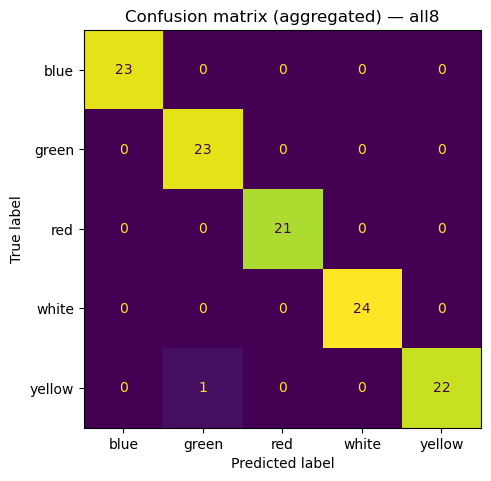

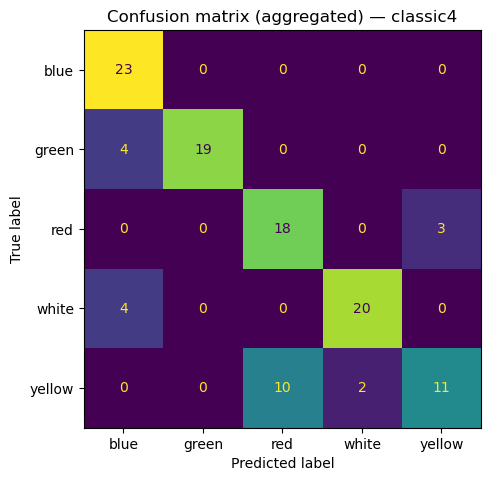

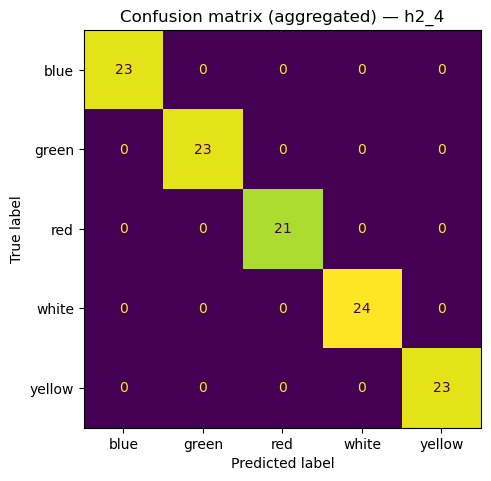

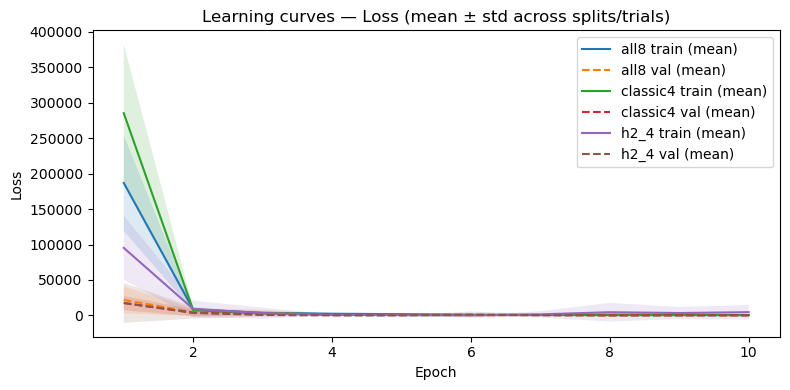

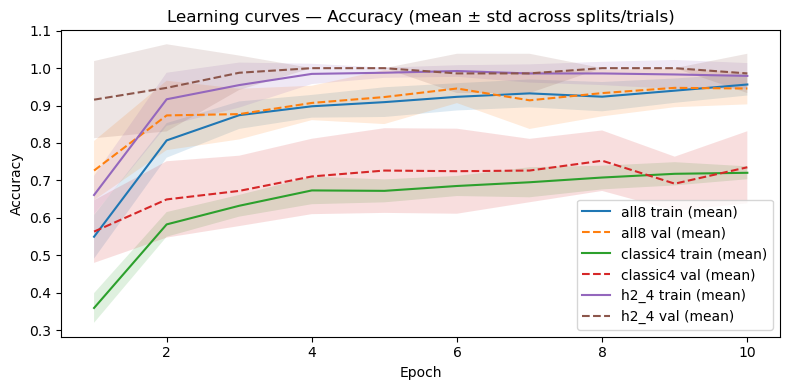

In [8]:
# Cell 8 — Evaluation + comparisons  

try:                                                                                      # CHANGE: allow this cell to run even if executed standalone (without Cell 7 already defining df_summary)
    df_summary                                                                             # CHANGE: reference check — if df_summary exists, do nothing
except NameError:                                                                          # CHANGE: if df_summary is missing, rebuild it from results_summary (if available)
    df_summary = pd.DataFrame(results_summary)                                             # CHANGE: fallback — create df_summary from in-memory results_summary so evaluation can proceed

try:                                                                                      # CHANGE: allow this cell to run even if executed standalone (without Cell 1 already defining device)
    device                                                                                 # CHANGE: reference check — if device exists, do nothing
except NameError:                                                                          # CHANGE: if device is missing, define a safe default
    device = torch.device("cpu")                                                           # CHANGE: fallback device so evaluation works even if Cell 1 wasn't run

# run the model on a DataLoader and collect predictions 
@torch.no_grad()                                                                          # no gradients needed for evaluation
def predict_on_loader(model, dataloader, device=device):                                  # CHANGE: add device arg so eval works correctly on CPU/GPU and in multi-run loops
    model.eval()                                                                          # set model to eval mode
    y_true_parts = []                                                                     # store true labels (chunks)
    y_pred_parts = []                                                                     # store predicted labels (chunks)
    sid_parts = []                                                                        # CHANGE: store global stimulus ids aligned to y_true/y_pred (needed for misclassification logging)
    offset = 0                                                                            # CHANGE: track position within dataloader.dataset so we can map batches -> dataset.indices deterministically (requires shuffle=False)
    for xb, yb in dataloader:                                                             # loop over minibatches
        bs = int(yb.shape[0])                                                             # CHANGE: batch size used to slice dataset.indices for stimulus ids
        xb = xb.to(device=device, dtype=torch.float32)                                    # CHANGE: move inputs to device and ensure float32
        yb = yb.to(device=device, dtype=torch.long)                                       # CHANGE: move labels to device and ensure int64
        logits, _ = model(xb)                                                             # forward pass (logits + latent)
        preds = torch.argmax(logits, dim=1)                                               # predicted class per sample
        y_true_parts.append(yb.detach().cpu().numpy())                                    # CHANGE: collect true labels on CPU (detached) for safety
        y_pred_parts.append(preds.detach().cpu().numpy())                                 # CHANGE: collect predicted labels on CPU (detached) for safety
        if hasattr(dataloader, "dataset") and hasattr(dataloader.dataset, "indices"):     # CHANGE: map batch rows -> global stimulus ids without modifying Dataset class
            sids_batch = np.asarray(dataloader.dataset.indices[offset:offset+bs], dtype=int)  # CHANGE: slice dataset.indices in order (only valid when shuffle=False)
        else:                                                                             # CHANGE: if dataset.indices is unavailable, fall back to placeholder ids
            sids_batch = np.full((bs,), -1, dtype=int)                                    # CHANGE: placeholder ids (misclassification logging will be limited)
        sid_parts.append(sids_batch)                                                      # CHANGE: store stimulus ids aligned to predictions
        offset += bs                                                                      # CHANGE: advance offset for next batch slice
    y_true = np.concatenate(y_true_parts, axis=0)                                         # stitch all batches into one array
    y_pred = np.concatenate(y_pred_parts, axis=0)                                         # stitch all batches into one array
    sids = np.concatenate(sid_parts, axis=0)                                              # CHANGE: stitch all stimulus-id batches into one array
    return y_true, y_pred, sids                                                           # CHANGE: return stimulus ids too (supports misclassification record-keeping)

# Runs to evaluate
run_order = ["all8", "classic4", "h2_4"]                                                   # consistent run order for prints/plots

# Containers to keep results in memory for saving
eval_rows = []                                                                            # list of dicts for a summary table later
conf_mats = {}                                                                            # dict: eval_key -> confusion matrix (keyed by run/split/trial to avoid collisions in multi-run mode)  # CHANGE: clarified keying for multi-run
reports = {}                                                                              # dict: eval_key -> text classification report (keyed by run/split/trial to avoid collisions in multi-run mode)  # CHANGE: clarified keying for multi-run
misclassified_rows = []                                                                   # CHANGE: list of dicts logging which RGB stimuli were misclassified on test (per run/split/trial)

# Choose which checkpoints to evaluate (best per run+split by default, to avoid an explosion of plots)
EVAL_SELECTION = "best_per_run_split"                                                     # CHANGE: options: "best_per_run_split" (recommended) or "all" (evaluate every row in df_summary)
if EVAL_SELECTION == "all":                                                               # CHANGE: evaluate every checkpoint row (can be many)
    df_to_eval = df_summary.copy()                                                        # CHANGE: evaluate all rows
else:                                                                                     # CHANGE: default path — evaluate only the best test_acc per (run, split_seed)
    df_to_eval = (                                                                        # CHANGE: build a filtered table with one row per (run, split_seed)
        df_summary.sort_values("test_acc", ascending=False)                               # CHANGE: sort so the best test_acc comes first within each group
        .groupby(["run", "split_seed"], as_index=False)                                   # CHANGE: group by run and split_seed so we keep the best trial per split
        .head(1)                                                                          # CHANGE: keep the single best row in each group
        .reset_index(drop=True)                                                           # CHANGE: clean up index after filtering
    )

# Evaluate each selected checkpoint on its corresponding test split
for row_i in range(len(df_to_eval)):                                                      # CHANGE: loop row-wise so we can access split_seed/trial/init_seed and checkpoint path
    row = df_to_eval.iloc[row_i]                                                          # CHANGE: fetch row as a Series for easy field access
    run_name = str(row["run"])                                                            # CHANGE: run identifier ("all8", "classic4", "h2_4")
    split_seed = int(row.get("split_seed", 0))                                             # CHANGE: dataset split seed used for this checkpoint (default 0 if missing)
    trial = int(row.get("trial", 0))                                                      # CHANGE: init trial index used for this checkpoint (default 0 if missing)
    init_seed = int(row.get("init_seed", 0))                                              # CHANGE: init seed used for this checkpoint (default 0 if missing)
    ckpt_path = str(row["checkpoint"])                                                    # CHANGE: checkpoint file path to load for evaluation
    eval_key = (run_name, split_seed, trial, init_seed)                                   # CHANGE: unique key for dicts so multi-run results don't overwrite each other

    keys_subset = channel_sets[run_name]                                                  # CHANGE: channel keys for this run (from Cell 7 mapping)
    train_idx_s, val_idx_s, test_idx_s = make_stratified_splits(                          # CHANGE: rebuild split indices from split_seed so evaluation matches the training split exactly
        all_idx=all_idx, y=y, split_seed=split_seed, test_frac=TEST_FRAC, val_frac=VAL_FRAC  # CHANGE: explicit args for reproducibility and correct alignment
    )

    dl_train, dl_val, dl_test, ds_train, ds_val, ds_test, C_run = make_loaders_for_keys(  # CHANGE: rebuild loaders/datasets for this run + split (new signature from Cell 7)
        keys_subset=keys_subset,                                                          # CHANGE: pass channel subset keys
        train_idx=train_idx_s,                                                            # CHANGE: pass split-specific train indices
        val_idx=val_idx_s,                                                                # CHANGE: pass split-specific val indices
        test_idx=test_idx_s,                                                              # CHANGE: pass split-specific test indices
        shuffle_seed=0                                                                    # CHANGE: shuffle seed irrelevant for test eval; 0 keeps deterministic behavior
    )

    x0, y0 = ds_test[0]                                                                   # CHANGE: grab a single sample so we can initialize LazyLinear before loading weights
    xb0 = x0.unsqueeze(0)                                                                 # CHANGE: add batch dimension (B=1) for model forward shape

    model = build_seeded_model(                                                           # CHANGE: build a model skeleton on the right device with LazyLinear initialized
        in_channels=C_run,                                                                # CHANGE: correct input channels for this run
        n_classes=n_classes,                                                              # CHANGE: correct output classes
        init_seed=0,                                                                      # CHANGE: seed irrelevant once we load checkpoint, but used to construct deterministically
        device=device,                                                                    # CHANGE: place model on active device
        example_batch=xb0                                                                 # CHANGE: trigger LazyLinear initialization so state_dict loads cleanly
    )
    criterion = nn.CrossEntropyLoss()                                                     # CHANGE: create criterion for completeness (eval loss uses it)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))                      # CHANGE: load trained weights onto the active device (CPU/GPU safe)

    y_true, y_pred, sids = predict_on_loader(model, dl_test, device=device)               # CHANGE: run test predictions and collect stimulus ids for logging
    test_acc = float((y_true == y_pred).mean())                                           # compute test accuracy

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))                    # confusion matrix (int labels)
    conf_mats[eval_key] = cm                                                              # CHANGE: store matrix keyed by (run, split_seed, trial, init_seed)

    report_txt = classification_report(                                                   # per-class precision/recall/F1
        y_true,                                                                           # true labels
        y_pred,                                                                           # predicted labels
        labels=np.arange(n_classes),                                                      # ensure stable label order
        target_names=class_names,                                                         # show hue names
        digits=4,                                                                         # print 4 decimals
        zero_division=0                                                                   # avoid warnings if any class missing
    )
    reports[eval_key] = report_txt                                                        # CHANGE: store report keyed by (run, split_seed, trial, init_seed)

    # Log misclassified stimulus ids (for saving later in Block 9)
    bad_mask = (y_true != y_pred)                                                         # CHANGE: boolean mask of misclassified samples
    bad_sids = np.asarray(sids[bad_mask], dtype=int)                                      # CHANGE: global stimulus ids for misclassified samples (aligns with imgs[stimulus_id])
    bad_true = np.asarray(y_true[bad_mask], dtype=int)                                    # CHANGE: true class ints for misclassified samples
    bad_pred = np.asarray(y_pred[bad_mask], dtype=int)                                    # CHANGE: predicted class ints for misclassified samples
    for j in range(len(bad_sids)):                                                        # CHANGE: expand into one row per misclassified stimulus for easy CSV saving/filtering
        misclassified_rows.append({                                                       # CHANGE: append a record capturing run/split/trial + stimulus id + labels
            "run": run_name,                                                              # CHANGE: channel-set run name
            "split_seed": split_seed,                                                     # CHANGE: dataset split seed
            "trial": trial,                                                               # CHANGE: init trial index
            "init_seed": init_seed,                                                       # CHANGE: init seed
            "stimulus_id": int(bad_sids[j]),                                              # CHANGE: index into imgs and outs_fill (global stimulus id)
            "true_label_int": int(bad_true[j]),                                           # CHANGE: true label as int
            "pred_label_int": int(bad_pred[j]),                                           # CHANGE: predicted label as int
            "true_label": str(class_names[int(bad_true[j])]),                             # CHANGE: true label as hue string
            "pred_label": str(class_names[int(bad_pred[j])]),                             # CHANGE: predicted label as hue string
            "checkpoint": ckpt_path                                                        # CHANGE: checkpoint responsible for this result (reproducibility)
        })

    eval_rows.append({                                                                    # CHANGE: store summary row (now includes split/trial/init for multi-run experiments)
        "run": run_name,                                                                  # run name
        "split_seed": split_seed,                                                         # CHANGE: dataset split seed used
        "trial": trial,                                                                   # CHANGE: init trial index used
        "init_seed": init_seed,                                                           # CHANGE: init seed used
        "n_channels": int(C_run),                                                         # number of channels used
        "epochs": int(row.get("epochs", EPOCHS)),                                          # CHANGE: epochs trained (from df_summary when available)
        "best_val_acc": float(row.get("best_val_acc", np.nan)),                           # CHANGE: best val acc from df_summary (already computed during training)
        "test_acc": test_acc,                                                             # final test accuracy (recomputed here)
        "checkpoint": ckpt_path                                                           # checkpoint filename
    })

    print("\n" + "=" * 70)                                                                # separator
    print(f"TEST EVAL — {run_name} | split_seed={split_seed} | trial={trial} | init_seed={init_seed} | n_channels={C_run} | checkpoint={ckpt_path}")  # CHANGE: print full identifiers for multi-run
    print(f"Test accuracy: {test_acc:.4f}")                                               # test accuracy
    print("Confusion matrix (rows=true, cols=pred):")                                     # confusion matrix label
    print(cm)                                                                             # print confusion matrix
    print("\nClassification report:")                                                     # report label
    print(report_txt)                                                                     # print report

# Make an in-memory summary table 
df_eval = pd.DataFrame(eval_rows).sort_values(["run", "split_seed", "trial"])             # CHANGE: build DataFrame and sort for readability in multi-run experiments
print("\n" + "=" * 70)                                                                    # separator
print("EVAL SUMMARY (in memory; saving happens in Block 9):")                             # header
display(df_eval)                                                                          # show the table

# Aggregate confusion matrices per run (sum across evaluated splits/trials) for compact visualization
conf_mats_by_run = {rn: np.zeros((n_classes, n_classes), dtype=int) for rn in run_order}  # CHANGE: initialize per-run aggregate confusion matrices
for eval_key, cm in conf_mats.items():                                                    # CHANGE: iterate over all evaluated confusion matrices
    rn = eval_key[0]                                                                      # CHANGE: extract run_name from eval_key tuple
    if rn in conf_mats_by_run:                                                            # CHANGE: safety check (only aggregate known runs)
        conf_mats_by_run[rn] += cm                                                        # CHANGE: sum counts across splits/trials (gives overall behavior per channel-set)

for run_name in run_order:                                                                # CHANGE: plot one aggregated confusion matrix per run (keeps figures manageable)
    cm = conf_mats_by_run[run_name]                                                       # CHANGE: aggregated confusion matrix for this run
    fig, ax = plt.subplots(figsize=(5, 5))                                                # CHANGE: new figure for aggregated confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)        # CHANGE: build display object
    disp.plot(ax=ax, values_format="d", colorbar=False)                                   # CHANGE: draw matrix (counts)
    ax.set_title(f"Confusion matrix (aggregated) — {run_name}")                           # CHANGE: title clarifies aggregation across splits/trials
    plt.tight_layout()                                                                    # tidy layout
    plt.show()                                                                            # show plot

# Plot learning curves (mean ± std across evaluated trials/splits) for each run on same axes
def _stack_histories(run_name):                                                           # CHANGE: helper to gather histories for a run across splits/trials into stacked arrays
    hs = []                                                                               # CHANGE: list to collect history dicts
    if isinstance(all_histories.get(run_name, None), dict):                               # CHANGE: new all_histories structure is dict: run -> split_seed -> [histories]
        for split_seed, h_list in all_histories[run_name].items():                        # CHANGE: iterate splits for this run
            for h in h_list:                                                              # CHANGE: iterate trials for this split
                hs.append(h)                                                              # CHANGE: collect each history
    elif isinstance(all_histories.get(run_name, None), list):                             # CHANGE: fallback if all_histories is a list (older notebook behavior)
        hs = all_histories[run_name]                                                      # CHANGE: keep compatibility with older structure
    return hs                                                                             # CHANGE: return list of histories

epochs = np.arange(1, EPOCHS + 1)                                                         # epoch numbers (1..EPOCHS)

plt.figure(figsize=(8, 4))                                                                # figure for loss curves
for run_name in run_order:                                                                # loop over runs
    hs = _stack_histories(run_name)                                                       # CHANGE: get all histories for this run (across splits/trials)
    if len(hs) == 0:                                                                      # CHANGE: skip if no histories are available
        continue                                                                          # CHANGE: nothing to plot
    L = min(len(h["train_loss"]) for h in hs)                                             # CHANGE: robust epoch length if any history differs (should all be EPOCHS)
    tr = np.vstack([np.asarray(h["train_loss"][:L], dtype=float) for h in hs])            # CHANGE: stack train loss curves across histories
    va = np.vstack([np.asarray(h["val_loss"][:L], dtype=float) for h in hs])              # CHANGE: stack val loss curves across histories
    e = np.arange(1, L + 1)                                                               # CHANGE: epoch axis matching truncated length
    tr_m, tr_s = tr.mean(axis=0), tr.std(axis=0)                                          # CHANGE: mean/std train loss across splits/trials
    va_m, va_s = va.mean(axis=0), va.std(axis=0)                                          # CHANGE: mean/std val loss across splits/trials
    plt.plot(e, tr_m, label=f"{run_name} train (mean)")                                   # CHANGE: plot mean train loss
    plt.fill_between(e, tr_m - tr_s, tr_m + tr_s, alpha=0.15)                             # CHANGE: show variability band (std) without specifying colors
    plt.plot(e, va_m, linestyle="--", label=f"{run_name} val (mean)")                     # CHANGE: plot mean val loss (dashed)
    plt.fill_between(e, va_m - va_s, va_m + va_s, alpha=0.15)                             # CHANGE: show variability band (std) for val loss
plt.xlabel("Epoch")                                                                       # x label
plt.ylabel("Loss")                                                                        # y label
plt.title("Learning curves — Loss (mean ± std across splits/trials)")                     # CHANGE: title clarifies aggregated visualization
plt.legend()                                                                              # legend
plt.tight_layout()                                                                        # tidy layout
plt.show()                                                                                # show plot

plt.figure(figsize=(8, 4))                                                                # figure for accuracy curves
for run_name in run_order:                                                                # loop over runs
    hs = _stack_histories(run_name)                                                       # CHANGE: get all histories for this run (across splits/trials)
    if len(hs) == 0:                                                                      # CHANGE: skip if no histories are available
        continue                                                                          # CHANGE: nothing to plot
    L = min(len(h["train_acc"]) for h in hs)                                              # CHANGE: robust epoch length if any history differs (should all be EPOCHS)
    tr = np.vstack([np.asarray(h["train_acc"][:L], dtype=float) for h in hs])             # CHANGE: stack train accuracy curves across histories
    va = np.vstack([np.asarray(h["val_acc"][:L], dtype=float) for h in hs])               # CHANGE: stack val accuracy curves across histories
    e = np.arange(1, L + 1)                                                               # CHANGE: epoch axis matching truncated length
    tr_m, tr_s = tr.mean(axis=0), tr.std(axis=0)                                          # CHANGE: mean/std train acc across splits/trials
    va_m, va_s = va.mean(axis=0), va.std(axis=0)                                          # CHANGE: mean/std val acc across splits/trials
    plt.plot(e, tr_m, label=f"{run_name} train (mean)")                                   # CHANGE: plot mean train accuracy
    plt.fill_between(e, tr_m - tr_s, tr_m + tr_s, alpha=0.15)                             # CHANGE: variability band (std) without specifying colors
    plt.plot(e, va_m, linestyle="--", label=f"{run_name} val (mean)")                     # CHANGE: plot mean val accuracy (dashed)
    plt.fill_between(e, va_m - va_s, va_m + va_s, alpha=0.15)                             # CHANGE: variability band (std) for val accuracy
plt.xlabel("Epoch")                                                                       # x label
plt.ylabel("Accuracy")                                                                    # y label
plt.title("Learning curves — Accuracy (mean ± std across splits/trials)")                 # CHANGE: title clarifies aggregated visualization
plt.legend()                                                                              # legend
plt.tight_layout()                                                                        # tidy layout
plt.show()                                                                                # show plot


In [9]:
# Cell 9 — Save evaluation outputs (summary CSV + confusion matrices)  

assert "df_eval" in globals(), "df_eval not found. Run Cell 8 first."            # summary table from Cell 8
assert "conf_mats" in globals(), "conf_mats not found. Run Cell 8 first."        # confusion matrices dict from Cell 8
assert "class_names" in globals(), "class_names not found. Run Cell 3 first."    # label names from LabelEncoder
assert "run_order" in globals(), "run_order not found. Run Cell 8 first."        # run order list from Cell 8

try:                                                                            # CHANGE: ensure json is available (Cell 1 now imports json, but this keeps Cell 9 robust if run standalone)
    json                                                                          # CHANGE: reference check — if json exists, do nothing
except NameError:                                                                 # CHANGE: if json is missing, import it here to avoid NameError
    import json                                                                   # CHANGE: fallback import for JSON saving if Cell 1 wasn't run

from datetime import datetime                                                    # CHANGE: import datetime so timestamping is automated (no manual entry required)

# Output folder 
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")                          # CHANGE: auto-generate date+time stamp string at runtime (YYYYMMDD_HHMMSS)
OUT_DIR = ZARR_PATH.parent / f"cnn_eval_outputs_{RUN_TIMESTAMP}"                  # CHANGE: timestamped folder next to dataset.zarr so each run saves to a unique directory
OUT_DIR.mkdir(parents=True, exist_ok=True)                                        # create folder if needed

# Save the summary table (CSV) 
summary_csv = OUT_DIR / "cnn_eval_summary.csv"                                    # output CSV path
df_eval.to_csv(summary_csv, index=False)                                          # write summary table
print("Saved summary CSV:", summary_csv)                                          # confirm save

# Save misclassified test images/records (per run/split/trial/init)
mis_dir = OUT_DIR / "misclassified"                                               # CHANGE: subfolder for misclassification artifacts (CSV + optional PNGs)
mis_dir.mkdir(parents=True, exist_ok=True)                                        # CHANGE: create subfolder if needed

if "misclassified_rows" in globals():                                             # CHANGE: only attempt saving if Cell 8 produced misclassified_rows
    df_mis = pd.DataFrame(misclassified_rows)                                     # CHANGE: build a DataFrame for easy filtering + CSV export
    mis_csv = mis_dir / "misclassified_test_records.csv"                          # CHANGE: single CSV containing all misclassifications across runs/splits/trials
    df_mis.to_csv(mis_csv, index=False)                                           # CHANGE: write the misclassification records CSV
    print("Saved misclassified records CSV:", mis_csv)                            # CHANGE: confirm save
else:                                                                             # CHANGE: explicit message if misclassification logging wasn't run
    print("Note: misclassified_rows not found — skipping misclassification CSV (run Cell 8 first).")  # CHANGE: user-facing note

SAVE_MISCLASSIFIED_PNGS = False                                                   # CHANGE: toggle to save RGB PNGs for misclassified stimuli (can be large); default False to keep disk use reasonable
MAX_MIS_PNGS_PER_GROUP = 50                                                       # CHANGE: safety cap per (run, split_seed, trial, init_seed) to avoid writing thousands of images

if SAVE_MISCLASSIFIED_PNGS:                                                       # CHANGE: optional block to write PNGs of misclassified RGB images
    try:                                                                          # CHANGE: import inside guarded block to avoid adding global dependency when not saving images
        from PIL import Image                                                     # CHANGE: Pillow image writer (commonly available; if missing you can pip install pillow)
        _PIL_OK = True                                                            # CHANGE: flag indicating PIL import succeeded
    except Exception as e:                                                        # CHANGE: handle missing Pillow gracefully
        _PIL_OK = False                                                           # CHANGE: flag indicating PIL import failed
        print("Warning: Pillow (PIL) not available; cannot save PNGs. Error:", e) # CHANGE: explain why PNG save is skipped

    if _PIL_OK and ("misclassified_rows" in globals()):                           # CHANGE: proceed only if we have data and PIL
        df_mis = pd.DataFrame(misclassified_rows)                                 # CHANGE: ensure df_mis exists in this scope
        grouped = df_mis.groupby(["run", "split_seed", "trial", "init_seed"])      # CHANGE: group so we can write images into organized folders
        for (run_name, split_seed, trial, init_seed), g in grouped:               # CHANGE: loop each group for tidy folder structure
            g_dir = mis_dir / f"{run_name}" / f"split{int(split_seed)}" / f"trial{int(trial)}_init{int(init_seed)}"  # CHANGE: hierarchical output path
            g_dir.mkdir(parents=True, exist_ok=True)                              # CHANGE: create group folder
            g_small = g.head(int(MAX_MIS_PNGS_PER_GROUP))                         # CHANGE: cap number of PNGs per group to avoid runaway output
            for _, r in g_small.iterrows():                                       # CHANGE: iterate misclassified rows for this group (up to cap)
                sid = int(r["stimulus_id"])                                       # CHANGE: global stimulus id indexing imgs (N,H,W,3)
                img = imgs[sid]                                                   # CHANGE: fetch RGB image array for this stimulus id
                img_u8 = img                                                      # CHANGE: placeholder for conversion
                if img_u8.dtype != np.uint8:                                      # CHANGE: if not uint8, convert safely for PNG writing
                    img_u8 = np.clip(img_u8, 0, 255).astype(np.uint8)             # CHANGE: clip to [0,255] and cast to uint8 (assumes image is already in 0..255 or close)
                fname = (                                                         # CHANGE: informative filename embeds id + true/pred labels for quick browsing
                    f"sid{sid:06d}_true{r['true_label']}_pred{r['pred_label']}.png"
                )
                Image.fromarray(img_u8).save(g_dir / fname)                       # CHANGE: write PNG to disk
        print("Saved misclassified PNGs under:", mis_dir)                         # CHANGE: confirm save location

# Save confusion matrices -
cm_dir = OUT_DIR / "confusion_matrices"                                           # subfolder for confusion matrices
cm_dir.mkdir(parents=True, exist_ok=True)                                         # create subfolder

combined = {}                                                                     # store all confusion matrices in one file too

# Save per-eval-key confusion matrices (supports multi-run by (run, split_seed, trial, init_seed))
for eval_key, cm in conf_mats.items():                                            # CHANGE: iterate over all evaluated confusion matrices (keys are tuples in multi-run mode)
    if isinstance(eval_key, tuple):                                               # CHANGE: expected new key type: (run, split_seed, trial, init_seed)
        run_name, split_seed, trial, init_seed = eval_key                         # CHANGE: unpack key fields for filenames + metadata
        key_str = f"{run_name}_split{int(split_seed)}_trial{int(trial)}_init{int(init_seed)}"  # CHANGE: stable string for filenames
    else:                                                                         # CHANGE: backward compatibility: old key type was just run_name string
        run_name = str(eval_key)                                                  # CHANGE: treat key as run name
        split_seed, trial, init_seed = 0, 0, 0                                    # CHANGE: defaults for legacy single-run notebooks
        key_str = f"{run_name}"                                                   # CHANGE: legacy filename prefix

    cm = np.asarray(cm, dtype=int)                                                # CHANGE: ensure plain int array (already int, but safe)
    cm_obj = {                                                                    # CHANGE: JSON-friendly object now includes split/trial/init for reproducibility
        "run": str(run_name),                                                     # CHANGE: run name
        "split_seed": int(split_seed),                                            # CHANGE: dataset split seed used for this eval
        "trial": int(trial),                                                      # CHANGE: init trial index used for this eval
        "init_seed": int(init_seed),                                              # CHANGE: init seed used for this eval
        "class_names": list(class_names),                                         # label names in matrix order
        "confusion_matrix": cm.tolist()                                           # matrix as nested Python lists
    }
    combined[key_str] = cm_obj                                                    # CHANGE: store in combined dict keyed by unique key_str (avoids collisions across trials/splits)

    cm_path = cm_dir / f"confusion_matrix_{key_str}.json"                         # CHANGE: per-eval JSON path includes split/trial/init to prevent overwrites
    with open(cm_path, "w") as f:                                                 # open file for writing
        json.dump(cm_obj, f, indent=2)                                            # save pretty JSON
    print("Saved confusion matrix JSON:", cm_path)                                # confirm save

combined_path = cm_dir / "confusion_matrices_all_evals.json"                      # CHANGE: combined JSON now includes all evaluated checkpoints, not just 3 runs
with open(combined_path, "w") as f:                                               # open file for writing
    json.dump(combined, f, indent=2)                                              # save all evals together
print("Saved combined confusion matrices JSON:", combined_path)                   # confirm save

# 3) Save a copy of the label mapping (int, hue)
label_map = {int(i): str(name) for i, name in enumerate(class_names)}             # encoder mapping
label_map_path = OUT_DIR / "label_mapping.json"                                   # mapping file path
with open(label_map_path, "w") as f:                                              # open file
    json.dump(label_map, f, indent=2)                                             # save mapping
print("Saved label mapping JSON:", label_map_path)                                # confirm save

# 4) Save evaluation reports (classification_report text)
reports_path = OUT_DIR / "classification_reports.txt"                             # CHANGE: write all classification reports to one text file for easy review/sharing
with open(reports_path, "w") as f:                                                # CHANGE: open file for writing
    for eval_key, report_txt in reports.items():                                  # CHANGE: iterate all reports (keyed by eval tuple in multi-run mode)
        f.write("=" * 80 + "\n")                                                  # CHANGE: separator between reports
        f.write(f"EVAL KEY: {eval_key}\n")                                        # CHANGE: write eval identifier (run/split/trial/init)
        f.write(report_txt + "\n\n")                                              # CHANGE: write report text
print("Saved classification reports TXT:", reports_path)                          # CHANGE: confirm save

# 5) Print a quick directory listing
print("\nWrote files:")                                                          # header
for p in sorted(OUT_DIR.rglob("*")):                                              # walk output folder
    if p.is_file():                                                              # only print files
        print(" -", p)                                                           # show saved file paths


Saved summary CSV: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs_20260122_212310/cnn_eval_summary.csv
Saved misclassified records CSV: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs_20260122_212310/misclassified/misclassified_test_records.csv
Saved confusion matrix JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs_20260122_212310/confusion_matrices/confusion_matrix_all8_split0_trial0_init0.json
Saved confusion matrix JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs_20260122_212310/confusion_matrices/confusion_matrix_h2_4_split0_trial0_init0.json
Saved confusion matrix JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs_20260122_21231